In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_dir = '/content/drive/MyDrive/HAM10000'
split_dir = os.path.join(base_dir, 'splits')
raw_dir = os.path.join(base_dir, 'raw')

part1_dir = os.path.join(raw_dir, 'HAM10000_images_part_1')
part2_dir = os.path.join(raw_dir, 'HAM10000_images_part_2')

In [ ]:
# ====================== LOAD CSV ======================
train_df = pd.read_csv(os.path.join(split_dir, 'train_split.csv'))
val_df   = pd.read_csv(os.path.join(split_dir, 'val_split.csv'))
test_df  = pd.read_csv(os.path.join(split_dir, 'test_split.csv'))

class_names = np.load(os.path.join(base_dir, 'class_names.npy'), allow_pickle=True).tolist()

print(f"✅ Load splits thành công!")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Classes: {class_names}")
print(f"\nCác cột trong train_df: {train_df.columns.tolist()}")

# ====================== XÁC ĐỊNH CỘT QUAN TRỌNG ======================
image_col = 'image_id'
label_col = 'dx'
print(f"→ Sử dụng cột ảnh: '{image_col}' | cột nhãn: '{label_col}'")

# ====================== THÊM ĐUÔI .jpg + TẠO ĐƯỜNG DẪN ĐẦY ĐỦ ======================
for df in [train_df, val_df, test_df]:
    # Thêm đuôi .jpg nếu chưa có
    df[image_col] = df[image_col].astype(str).apply(lambda x: x if x.lower().endswith('.jpg') else x + '.jpg')

    # Ưu tiên dùng cột image_path nếu có và hợp lệ, ngược lại tự tìm trong 2 part
    if 'image_path' in df.columns:
        df['full_path'] = df['image_path'].where(df['image_path'].notna() & df['image_path'].astype(str).str.contains('HAM10000_images'), None)

    # Nếu chưa có full_path hợp lệ thì tìm trong part_1 và part_2
    def find_image_path(img_name):
        for part_dir in [part1_dir, part2_dir]:
            path = os.path.join(part_dir, img_name)
            if os.path.exists(path):
                return path
        return None

    mask = df.get('full_path', pd.Series([None]*len(df))).isnull()
    df.loc[mask, 'full_path'] = df.loc[mask, image_col].apply(find_image_path)

# Kiểm tra ảnh bị thiếu
missing_train = train_df['full_path'].isnull().sum()
if missing_train > 0:
    print(f"⚠️ Cảnh báo: {missing_train} ảnh trong train không tìm thấy!")

✅ Load splits thành công!
Train: 7010 | Val: 1502 | Test: 1503
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Các cột trong train_df: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'label', 'image_path']
→ Sử dụng cột ảnh: 'image_id' | cột nhãn: 'dx'


✅ Train: 7010 | Val: 1502 | Test: 1503
Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


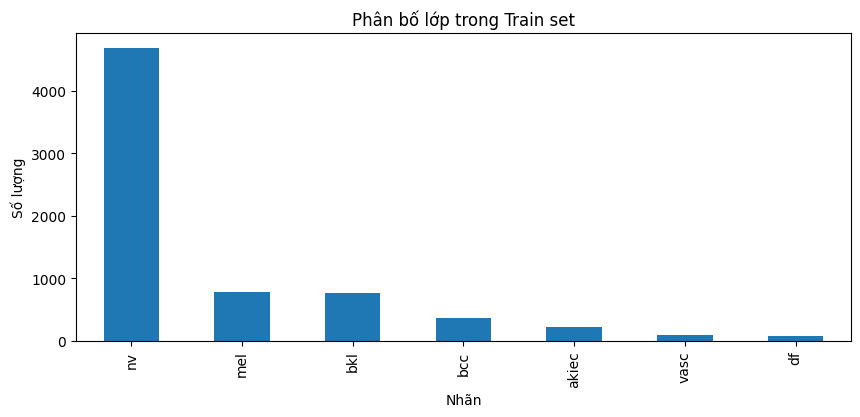

In [ ]:
print(f"✅ Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Classes ({len(class_names)}): {class_names}")

# Kiểm tra class distribution
plt.figure(figsize=(10,4))
train_df['dx'].value_counts().plot(kind='bar')
plt.title('Phân bố lớp trong Train set')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.show()

In [ ]:
import os, random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# -------- config --------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('✅ Device:', device)

NUM_CLASSES = 7
EPOCHS = 50
batch_size = 32  # Giảm batch size để phù hợp với ảnh lớn hơn
img_size = 224 # Tăng kích thước ảnh

# cố định mapping theo class_names.npy để không lệch index
if 'class_names' not in globals() or class_names is None or len(class_names) == 0:
    class_names = sorted(train_df[label_col].unique().tolist())
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

# -------- rare classes (giữ để tham khảo) --------
class_counts = train_df[label_col].value_counts().sort_index()
rare_threshold = max(120, int(class_counts.quantile(0.40)))
rare_classes = class_counts[class_counts <= rare_threshold].index.tolist()
print(f"Ngưỡng lớp hiếm: <= {rare_threshold} mẫu")
print(f"Các lớp hiếm (tham khảo): {rare_classes}")

# -------- transforms (augment nhẹ, gần với Keras augment trước) --------
train_tfms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.92, 1.08)),
    transforms.ToTensor(),  # -> [0,1]
])

val_tfms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

class HAM10000Dataset(Dataset):
    def __init__(self, df, transform, label_col='dx', class_to_idx=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col
        self.class_to_idx = class_to_idx or {c: i for i, c in enumerate(sorted(df[label_col].unique()))}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['full_path']).convert('RGB')
        img = self.transform(img)
        y = int(self.class_to_idx[row[self.label_col]])
        return img, y

train_dataset = HAM10000Dataset(train_df, transform=train_tfms, label_col=label_col, class_to_idx=class_to_idx)
val_dataset = HAM10000Dataset(val_df, transform=val_tfms, label_col=label_col, class_to_idx=class_to_idx)
test_dataset = HAM10000Dataset(test_df, transform=val_tfms, label_col=label_col, class_to_idx=class_to_idx)

# DataLoader: tăng tốc đọc Drive bằng workers + prefetch
NUM_WORKERS = 2 # Tăng số lượng worker để cải thiện tốc độ đọc dữ liệu
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)
print(f"✅ Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# -------- class weights (smoothed) --------
freq = class_counts.reindex(class_names).astype(float).fillna(0.0)
inv_freq = freq.max() / freq.replace(0.0, np.nan)
smoothed_weights = np.sqrt(inv_freq).replace([np.inf, np.nan], 1.0)
smoothed_weights = smoothed_weights / smoothed_weights.mean()
smoothed_weights = smoothed_weights.clip(lower=0.75, upper=3.20)
if 'mel' in smoothed_weights.index:
    smoothed_weights.loc['mel'] = min(3.20, smoothed_weights.loc['mel'] * 1.15)
smoothed_weights = smoothed_weights / smoothed_weights.mean()
class_weight_dict = {int(class_to_idx[c]): float(smoothed_weights.loc[c]) for c in class_names}

✅ Device: cuda
Ngưỡng lớp hiếm: <= 281 mẫu
Các lớp hiếm (tham khảo): ['akiec', 'df', 'vasc']
✅ Train batches: 220 | Val: 47 | Test: 47


In [ ]:
print("\n📊 Class weights (lightweight, smoothed):")
for i in range(len(class_names)):
    cls_name = idx_to_class[i]
    count = int((train_df[label_col] == cls_name).sum())
    rare_tag = "(RARE)" if cls_name in rare_classes else ""
    w = float(class_weight_dict.get(i, 1.0))
    print(f"  Lớp {i:2d} ({cls_name:>15}) | count={count:4d} | weight={w:.4f} {rare_tag}")

print("\n" + "="*80)
print("✅ DATA PIPELINE SẴN SÀNG!")
print("   • Augment: nhẹ")
print("   • img_size =", img_size, "| batch_size =", batch_size, "| workers =", NUM_WORKERS)
print("\nChạy cell tiếp theo để build & train CNN mới.")


📊 Class weights (lightweight, smoothed):
  Lớp  0 (          akiec) | count= 229 | weight=0.9819 (RARE)
  Lớp  1 (            bcc) | count= 360 | weight=0.7831 
  Lớp  2 (            bkl) | count= 769 | weight=0.6637 
  Lớp  3 (             df) | count=  81 | weight=1.6510 (RARE)
  Lớp  4 (            mel) | count= 779 | weight=0.7632 
  Lớp  5 (             nv) | count=4693 | weight=0.6637 
  Lớp  6 (           vasc) | count=  99 | weight=1.4934 (RARE)

✅ DATA PIPELINE SẴN SÀNG!
   • Augment: nhẹ
   • img_size = 224 | batch_size = 32 | workers = 2

Chạy cell tiếp theo để build & train CNN mới.


In [ ]:
# ====================== CHECKPOINT DIR (PYTORCH) ======================
import os
CKPT_DIR = os.path.join(base_dir, "checkpoints_custom_cnn_torch")
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_BEST = os.path.join(CKPT_DIR, "custom_cnn_best.pt")
CKPT_LAST = os.path.join(CKPT_DIR, "custom_cnn_last.pt")
print("✅ CKPT_DIR:", CKPT_DIR)

✅ CKPT_DIR: /content/drive/MyDrive/HAM10000/checkpoints_custom_cnn_torch


In [ ]:
# ====================== CUSTOM CNN (PYTORCH) ======================
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        # padding=1 để giữ HxW; MaxPool ceil_mode=True để 7->4 và 4->2
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
        )
        # với input 224x224 => pool: 224->112->56->28->14 => 14*14*128=25088
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(14 * 14 * 128, 64), # Cập nhật kích thước input cho Linear layer
            nn.ReLU(inplace=True),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CustomCNN(num_classes=NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"✅ Total parameters: {total_params:,}")

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=25088, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=64, out_features=32, bia

In [ ]:
# ====================== TRAIN UTILITIES (PYTORCH) ======================
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler # autocast here is the old deprecated one
from tqdm import tqdm
from sklearn.metrics import f1_score

# class weights tensor for CrossEntropyLoss
weight_tensor = torch.ones(NUM_CLASSES, dtype=torch.float32)
for i in range(NUM_CLASSES):
    weight_tensor[i] = float(class_weight_dict.get(i, 1.0))
weight_tensor = (weight_tensor / weight_tensor.mean()).to(device)

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# Update GradScaler initialization to use torch.amp.GradScaler if available/preferred
# For now, keep torch.cuda.amp.GradScaler as the warning is about autocast
scaler = GradScaler(enabled=(device.type == 'cuda'))

def train_one_epoch(model, loader, optimizer, criterion, device, epoch_idx):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f"Train Epoch {epoch_idx+1}", leave=True)
    for imgs, labels in pbar:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type='cuda', enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{(correct/total):.4f}")
    return total_loss / total, correct / total

@torch.no_grad()
def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct, total = 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="Valid", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.amp.autocast(device_type='cuda', enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total, acc, f1

/tmp/ipykernel_4609/3450380131.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == 'cuda'))


In [ ]:
# ====================== TRAIN LOOP (PYTORCH) ======================
import copy
best = {"val_acc": -1.0, "val_f1": -1.0, "val_loss": 1e9}
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

patience = 7
bad_epochs = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch)
    val_loss, val_acc, val_f1 = eval_model(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

    # save last
    torch.save({
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "history": history,
        "class_names": class_names,
        "img_size": img_size,
    }, CKPT_LAST)

    # best by (macro-F1, then acc)
    is_best = (val_f1 > best["val_f1"]) or (val_f1 == best["val_f1"] and val_acc > best["val_acc"])
    if is_best:
        best.update({"val_acc": float(val_acc), "val_f1": float(val_f1), "val_loss": float(val_loss)})
        torch.save({
            "epoch": epoch + 1,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best": best,
            "history": history,
            "class_names": class_names,
            "img_size": img_size,
        }, CKPT_BEST)
        print(f"🔥 BEST UPDATE => val_f1={best['val_f1']:.4f} val_acc={best['val_acc']:.4f}")
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"⏹ Early stopping (no improvement for {patience} epochs)")
            break

print("✅ Training done. Best:", best)

Train Epoch 1: 100%|██████████| 220/220 [01:28<00:00,  2.49it/s, acc=0.6573, loss=0.1416]


Epoch 1/50 | train_loss=1.1912 train_acc=0.6573 | val_loss=1.1007 val_acc=0.6684 val_f1=0.1145
🔥 BEST UPDATE => val_f1=0.1145 val_acc=0.6684


Train Epoch 2: 100%|██████████| 220/220 [01:31<00:00,  2.39it/s, acc=0.6679, loss=0.1658]


Epoch 2/50 | train_loss=1.0771 train_acc=0.6679 | val_loss=1.0288 val_acc=0.6658 val_f1=0.1273
🔥 BEST UPDATE => val_f1=0.1273 val_acc=0.6658


Train Epoch 3: 100%|██████████| 220/220 [01:31<00:00,  2.41it/s, acc=0.6723, loss=1.7048]


...

Epoch 30/50 | train_loss=0.5861 train_acc=0.7840 | val_loss=0.7514 val_acc=0.7437 val_f1=0.5290


Train Epoch 31: 100%|██████████| 220/220 [01:30<00:00,  2.43it/s, acc=0.7906, loss=0.0008]


Epoch 31/50 | train_loss=0.5877 train_acc=0.7906 | val_loss=0.7258 val_acc=0.7750 val_f1=0.5702


Train Epoch 32: 100%|██████████| 220/220 [01:33<00:00,  2.35it/s, acc=0.7884, loss=0.0041]
                                                      

Epoch 32/50 | train_loss=0.5746 train_acc=0.7884 | val_loss=0.8044 val_acc=0.7630 val_f1=0.5594
⏹ Early stopping (no improvement for 7 epochs)
✅ Training done. Best: {'val_acc': 0.7643142476697736, 'val_f1': 0.5720073318830503, 'val_loss': 0.7517206008520012}


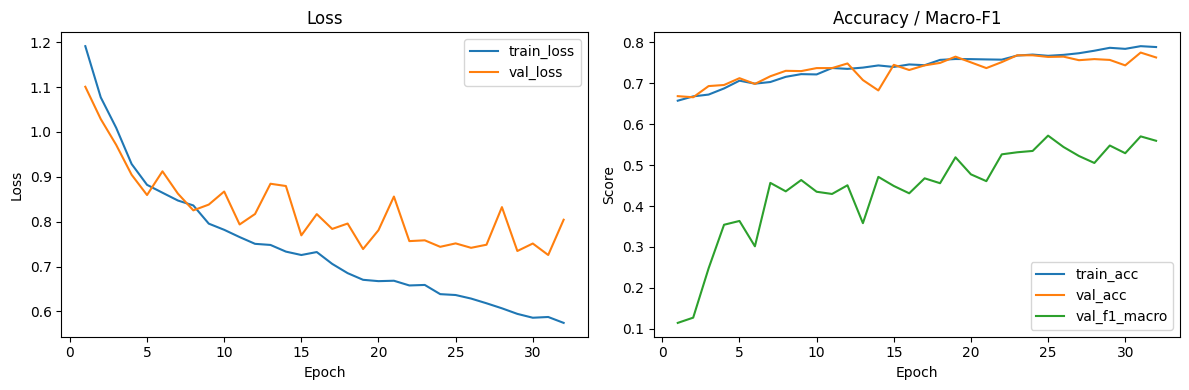

In [ ]:
# ====================== PLOT TRAINING CURVES (PYTORCH) ======================
import matplotlib.pyplot as plt
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="train_loss")
plt.plot(epochs_range, history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="train_acc")
plt.plot(epochs_range, history["val_acc"], label="val_acc")
plt.plot(epochs_range, history["val_f1"], label="val_f1_macro")
plt.title("Accuracy / Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()
plt.show()

✅ Loaded best checkpoint



TEST | loss=0.7675 | acc=0.7458 | f1_macro=0.5097


Testing:   0%|          | 0/47 [00:00<?, ?it/s]/tmp/ipykernel_4609/1834530761.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):



Classification Report:
              precision    recall  f1-score   support

       akiec       0.44      0.37      0.40        49
         bcc       0.45      0.68      0.54        77
         bkl       0.44      0.36      0.40       165
          df       0.33      0.24      0.28        17
         mel       0.49      0.42      0.45       167
          nv       0.87      0.90      0.88      1006
        vasc       0.71      0.55      0.62        22

    accuracy                           0.75      1503
   macro avg       0.53      0.50      0.51      1503
weighted avg       0.74      0.75      0.74      1503



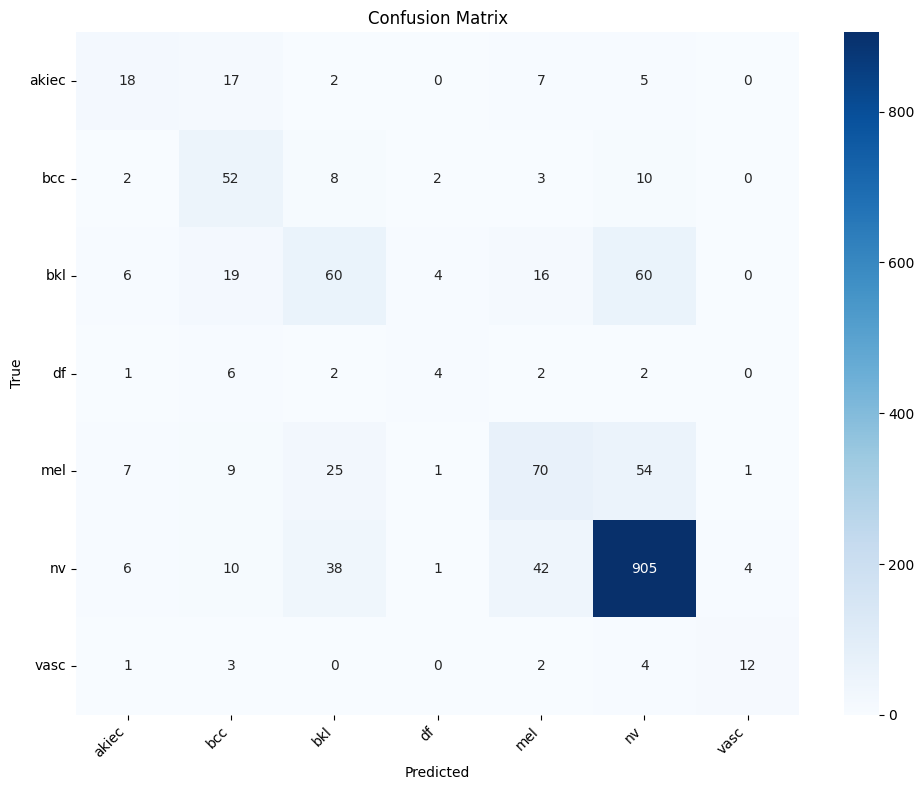

,precision,recall,f1-score,support
akiec,0.439024,0.367347,0.400000,49.0
bcc,0.448276,0.675325,0.538860,77.0
bkl,0.444444,0.363636,0.400000,165.0
df,0.333333,0.235294,0.275862,17.0
mel,0.492958,0.419162,0.453074,167.0


In [ ]:
# ====================== EVALUATE ON TEST (PYTORCH) ======================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# load best checkpoint
if os.path.exists(CKPT_BEST):
    ckpt = torch.load(CKPT_BEST, map_location=device)
    model.load_state_dict(ckpt["model_state"], strict=True)
    print("✅ Loaded best checkpoint")
else:
    print("⚠️ Best checkpoint not found, using current model")

test_loss, test_acc, test_f1 = eval_model(model, test_loader, criterion, device)
print(f"\nTEST | loss={test_loss:.4f} | acc={test_acc:.4f} | f1_macro={test_f1:.4f}")

# detailed report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs)
        preds = logits.argmax(1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

ordered_class_names = [idx_to_class[i] for i in range(len(class_names))]
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=ordered_class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ordered_class_names, yticklabels=ordered_class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

report = classification_report(all_labels, all_preds, target_names=ordered_class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head()

In [ ]:
# ====================== QUICK INFERENCE SANITY CHECK ======================
# Lấy 1 batch test để xem output shape
model.eval()
imgs, labels = next(iter(test_loader))
imgs = imgs.to(device, non_blocking=True)
with torch.no_grad():
    with autocast(enabled=(device.type == 'cuda')):
        logits = model(imgs)
print('✅ logits shape:', tuple(logits.shape))

✅ logits shape: (32, 7)


/tmp/ipykernel_4609/3576503048.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


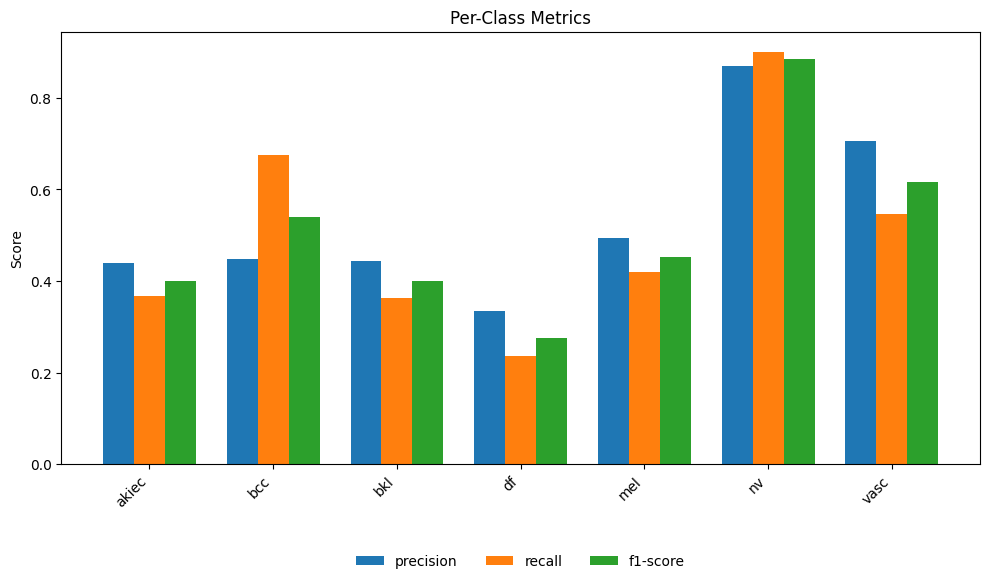

In [ ]:
# ====================== (OPTIONAL) PER-CLASS METRIC BARS ======================
import numpy as np
import matplotlib.pyplot as plt

if 'df_report' not in locals():
    print("⚠️ Chưa có df_report. Hãy chạy cell Evaluate trước.")
else:
    class_rows = df_report.index.difference(["accuracy", "macro avg", "weighted avg"])
    df_cls = df_report.loc[class_rows].copy()

    metrics = ["precision", "recall", "f1-score"]
    class_names_plot = df_cls.index.tolist()

    plt.figure(figsize=(10, 6))
    x = np.arange(len(class_names_plot))
    width = 0.25

    for i, m in enumerate(metrics):
        plt.bar(x + i * width, df_cls[m].values, width=width, label=m)

    plt.xticks(x + width, class_names_plot, rotation=45, ha='right')
    plt.ylabel("Score")
    plt.title("Per-Class Metrics")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()